In [1]:
# Import the below libraries:
"""For faster loading, consider importing the libraries in separate cells."""
# To create reproducible file paths
import os # To interact with the operating system
from pathlib import Path # To create Path objects
import pathlib # To access the object-oriented library for paths

# For unzipping folders
import time # To handle time-related tasks
import zipfile # To download and extract zip files

# For saving Python objects
import pickle # To pickle datasets that take long periods to process

# To use APIs
import requests # For sending API requests

# To download Global Biodiversity Information Facility (GBIF) data
from getpass import getpass # To obtain a GBIF login and password
import pygbif.occurrences as occ # To download species occurrence data from GBIF
import pygbif.species as species # To identify specific species datasets to download on GBIF

# To work with different types of data
import geopandas as gpd # To make GeoDataFrames/work with vector data
from glob import glob # To combine data arrays
from math import floor, ceil # For dealing with integers
import numpy as np # To work with arrays
import pandas as pd # To work with dataframes
import rasterio # For handling raster soil maps
import rioxarray as rxr # To work with raster data
import rioxarray.merge as rxrm # To merge raster data
from shapely.geometry import box # To create bounding boxes
from shapely.geometry import MultiPolygon, Polygon # To handle invalid geometries
import xarray as xr # To use xarray datasets

# For visualization and interactive plotting
import contextily as ctx # To restore geography to the base map
import holoviews as hv # To create interactive hvPlots
import hvplot.pandas # To enable hvPlot interactive plotting for Pandas dataframes
import hvplot.xarray # To enable hvPlot interactive plotting for xarray datasets
import matplotlib.gridspec as gridspec # To display the plot legends properly
import matplotlib.pyplot as plt # To import the Pyplot module
import pyproj # For converting axes ticks to degrees

In [2]:
# Create a designated folder for the GBIF and nutrient data
"""Note: the precise destination of the repository folder will vary from individual to individual."""
nutrient_data_dir = os.path.join(
    pathlib.Path.home(),
    # In the earth-analytics data folder
    'earth-analytics',
    'data',
    # Specify the destination as inside the "PLANT-B-Stoichiometric-Nutrient-Cycle-Simulation" repository
    'PLANT-B-Stoichiometric-Nutrient-Cycle-Simulation',
    'habitat_nutrient_concentrations_for_species'
)

# Create the directory
os.makedirs(nutrient_data_dir, exist_ok=True)

In [3]:
# Create a directory to store the GBIF data
gbif_dir = os.path.join(nutrient_data_dir, 'gbif_PLANT-B_dir')
os.makedirs(gbif_dir, exist_ok=True)

In [4]:
# Permanently log into GBIF
# Do not reset credentials to avoid repeated login requests
reset_credentials = False

# Request and store username
if (not ('GBIF_USER'  in os.environ)) or reset_credentials:
    os.environ['GBIF_USER'] = input('GBIF username:')

# Request and store password
if (not ('GBIF_PWD'  in os.environ)) or reset_credentials:
    os.environ['GBIF_PWD'] = getpass('GBIF password:')
    
# Request and store email address
if (not ('GBIF_EMAIL'  in os.environ)) or reset_credentials:
    os.environ['GBIF_EMAIL'] = input('GBIF email:')

In [5]:
# Check that the login attempt was successful
'GBIF_PWD' in os.environ

True

In [6]:
# Set the species names for the white dwarf isopod, the temperate white springtail, and the spreading earthmoss:
# White dwarf isopod
isopod_name = "Trichorhina tomentosa"
# Temperate white springtail
springtail_name = "Folsomia candida"
# Spreading earthmoss
moss_name = "Physcomitrium patens"

# Pull the species info from GBIF
isopod_info = species.name_lookup(isopod_name, rank = 'Species')
springtail_info = species.name_lookup(springtail_name, rank = 'Species')
moss_info = species.name_lookup(moss_name, rank = 'Species')

# Grab the second result for the white dwarf isopod and print it
"""The second result matches the desired dataset, pulled from https://www.gbif.org/species/2204981."""
isopod_result = isopod_info['results'][1]
print("\nWhite dwarf isopod (Trichorhina tomentosa):")
print(isopod_result)

# Grab the result for the temperate white springtail and print it
springtail_result = springtail_info['results'][0]
print("\nTemperate white springtail (Folsomia candida):")
print(springtail_result)

# Grab the result for the spreading earthmoss and print it
moss_result = moss_info['results'][0]
print("\nSpreading earthmoss (Physcomitrium patens):")
print(moss_result)


White dwarf isopod (Trichorhina tomentosa):
{'key': 145956763, 'datasetKey': '3f5e930b-52a5-461d-87ec-26ecd66f14a3', 'nubKey': 2204981, 'parentKey': 315793644, 'parent': 'Trichorhina', 'kingdom': 'Animalia', 'phylum': 'Arthropoda', 'genus': 'Trichorhina', 'species': 'Trichorhina tomentosa', 'kingdomKey': 315792181, 'phylumKey': 315793470, 'classKey': 315793535, 'genusKey': 315793644, 'speciesKey': 145956763, 'scientificName': 'Trichorhina tomentosa', 'canonicalName': 'Trichorhina tomentosa', 'nameType': 'SCIENTIFIC', 'taxonomicStatus': 'ACCEPTED', 'rank': 'SPECIES', 'origin': 'SOURCE', 'numDescendants': 0, 'numOccurrences': 0, 'taxonID': 'rinse-checklist:taxon:ab18f069b6b2207654fe78190efb3ef9', 'habitats': ['FRESHWATER'], 'nomenclaturalStatus': [], 'threatStatuses': [], 'descriptions': [], 'vernacularNames': [], 'synonym': False, 'higherClassificationMap': {'315792181': 'Animalia', '315793470': 'Arthropoda', '315793535': 'Malacostraca', '315793644': 'Trichorhina'}, 'class': 'Malacostr

In [7]:
# Get the species key for the dwarf white isopod
isopod_key = isopod_result['nubKey']

# Check what the isopod's species key is
isopod_name, isopod_key

('Trichorhina tomentosa', 2204981)

In [8]:
# Get the species key for the temperate white springtail
springtail_key = springtail_result['nubKey']

# Check what the springtail's species key is
springtail_name, springtail_key

('Folsomia candida', 2120383)

In [9]:
# Get the species key for the spreading earthmoss
moss_key = moss_result['nubKey']

# Check what the moss's species key is
moss_name, moss_key

('Physcomitrium patens', 8179907)

In [10]:
# Create a directory to store the isopod GBIF data
isopod_gbif_dir = os.path.join(gbif_dir, 'isopod_gbif_dir')
os.makedirs(isopod_gbif_dir, exist_ok=True)

# Create the file path for the isopod CSV
isopod_gbif_pattern = os.path.join(isopod_gbif_dir, '*.csv')

# Create a function to download the dwarf white isopod occurrence data
"""
Each download function must be given distinct pattern, data query, download key, and CSV path variables to avoid downloading the same GBIF 
dataset.

Variables:
isopod_gbif_query: GBIF query specific to the isopod download function
isopod_download_key: Download key for the isopod GBIF download
isopod_gbif_path: CSV file path for the isopod data download

Output: 
isopod_gbif_pattern: File name for the isopod GBIF CSV
"""
if not glob(isopod_gbif_pattern): # For the isopod data download, ensure the pattern used is "isopod_gbif_pattern"
    # Submit the query to GBIF
    isopod_gbif_query = occ.download([
        f"speciesKey = {isopod_key}", # For the isopod data download, ensure the key used is "isopod_key"
        "hasCoordinate = True", # For all datasets, only accept occurrence points that have longitude and latitude coordinates
    ])
    # Only download the data once
    isopod_download_key = isopod_gbif_query[0]
    os.environ['GBIF_DOWNLOAD_KEY'] = isopod_download_key
    time.sleep(5) # Let it rest before reattempting the download
    # Download the data
    isopod_download_info = occ.download_get(
        isopod_download_key,
        path = isopod_gbif_dir
    )
    # Unzip the file
    with zipfile.ZipFile(isopod_download_info['path']) as download_zip:
        download_zip.extractall(path = isopod_gbif_dir)

# Locate the CSV file path for the isopod data download
isopod_gbif_path = glob(isopod_gbif_pattern)[0]

In [11]:
# Look at the isopod download information
occ.download_meta("0008929-260409193756587") # Input the download key to view the information

{'key': '0008929-260409193756587',
 'doi': '10.15468/dl.trbbxx',
 'license': 'http://creativecommons.org/licenses/by-nc/4.0/legalcode',
 'request': {'predicate': {'type': 'and',
   'predicates': [{'type': 'equals',
     'key': 'SPECIES_KEY',
     'value': '2204981',
     'matchCase': False},
    {'type': 'equals',
     'key': 'HAS_COORDINATE',
     'value': 'True',
     'matchCase': False}]},
  'sendNotification': True,
  'format': 'SIMPLE_CSV',
  'type': 'OCCURRENCE',
  'verbatimExtensions': [],
  'interpretedExtensions': []},
 'created': '2026-04-12T23:40:56.768+00:00',
 'modified': '2026-04-12T23:42:34.715+00:00',
 'eraseAfter': '2026-10-12T23:40:56.642+00:00',
 'status': 'SUCCEEDED',
 'downloadLink': 'https://api.gbif.org/v1/occurrence/download/request/0008929-260409193756587.zip',
 'size': 12710,
 'totalRecords': 136,
 'numberDatasets': 27}

In [12]:
# Read the isopod CSV
isopod_gbif_df = pd.read_csv(
    isopod_gbif_path,
    delimiter = '\t'
)

# Check the dataframe
isopod_gbif_df

,gbifID,datasetKey,occurrenceID,kingdom,phylum,class,order,family,genus,species,...,identifiedBy,dateIdentified,license,rightsHolder,recordedBy,typeStatus,establishmentMeans,lastInterpreted,mediaType,issue
0,6181601810,9a0b66df-7535-4f28-9f4e-5bc11b8b096c,Natuurpunt:Waarnemingen:388844367,Animalia,Arthropoda,Malacostraca,Isopoda,Platyarthridae,Trichorhina,Trichorhina tomentosa,...,NaN,NaN,CC_BY_NC_4_0,Natuurpunt Studie,NaN,NaN,NaN,2026-04-08T12:16:39.820Z,NaN,OCCURRENCE_STATUS_INFERRED_FROM_INDIVIDUAL_COU...
1,6063817888,8a37280c-9310-4ce9-835c-5a14d35b84aa,87d3dd14-c448-4a89-9b46-6be963f7f9ed,Animalia,Arthropoda,Malacostraca,Isopoda,Platyarthridae,Trichorhina,Trichorhina tomentosa,...,NaN,NaN,CC_BY_NC_4_0,Biological Records Centre,"Rundle, A.J.",NaN,NaN,2026-04-09T09:02:58.489Z,NaN,CONTINENT_DERIVED_FROM_COORDINATES;RECORDED_DA...
2,6063711977,8a37280c-9310-4ce9-835c-5a14d35b84aa,4e891b08-f8b4-48fc-8e9a-df4925c518bc,Animalia,Arthropoda,Malacostraca,Isopoda,Platyarthridae,Trichorhina,Trichorhina tomentosa,...,NaN,NaN,CC_BY_NC_4_0,Biological Records Centre,"Rundle, A.J.",NaN,NaN,2026-04-09T09:02:33.039Z,NaN,CONTINENT_DERIVED_FROM_COORDINATES;RECORDED_DA...
3,5936573187,38b4c89f-584c-41bb-bd8f-cd1def33e92f,urn:lsid:artportalen.se:sighting:130331401,Animalia,Arthropoda,Malacostraca,Isopoda,Platyarthridae,Trichorhina,Trichorhina tomentosa,...,NaN,NaN,CC0_1_0,Freddy Persson,"Freddy Persson, Dennis Nyström",NaN,NaN,2026-04-11T17:14:21.269Z,NaN,NaN
4,5935958546,50c9509d-22c7-4a22-a47d-8c48425ef4a7,https://www.inaturalist.org/observations/33185...,Animalia,Arthropoda,Malacostraca,Isopoda,Platyarthridae,Trichorhina,Trichorhina tomentosa,...,Linda Kjær-Thomsen,2025-12-23T23:51:48,CC_BY_NC_4_0,Linda Kjær-Thomsen,Linda Kjær-Thomsen,NaN,NaN,2026-04-11T09:54:38.742Z,StillImage,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,1318795009,821cc27a-e3bb-4bc5-ac34-89ada245069d,http://n2t.net/ark:/65665/3466b26b7-27f5-4fa7-...,Animalia,Arthropoda,Malacostraca,Isopoda,Platyarthridae,Trichorhina,Trichorhina tomentosa,...,Verhoeff,NaN,CC0_1_0,NaN,Verhoeff,NaN,NaN,2026-04-02T11:43:16.464Z,StillImage,GEODETIC_DATUM_ASSUMED_WGS84;CONTINENT_DERIVED...
132,1054185903,2e4cc37b-302e-4f1b-bbbb-1f674ff90e14,28417,Animalia,Arthropoda,Malacostraca,Isopoda,Platyarthridae,Trichorhina,Trichorhina tomentosa,...,"Olsen, K.M.",NaN,CC_BY_4_0,NaN,"Olsen, K.M.",NaN,NaN,2026-04-12T12:15:09.680Z,NaN,COORDINATE_ROUNDED;GEODETIC_DATUM_ASSUMED_WGS8...
133,1054185717,2e4cc37b-302e-4f1b-bbbb-1f674ff90e14,28203,Animalia,Arthropoda,Malacostraca,Isopoda,Platyarthridae,Trichorhina,Trichorhina tomentosa,...,"Olsen, K.M.",NaN,CC_BY_4_0,NaN,"Olsen, K.M.",NaN,NaN,2026-04-12T12:15:11.438Z,NaN,COORDINATE_ROUNDED;GEODETIC_DATUM_ASSUMED_WGS8...
134,1054177305,2e4cc37b-302e-4f1b-bbbb-1f674ff90e14,08000,Animalia,Arthropoda,Malacostraca,Isopoda,Platyarthridae,Trichorhina,Trichorhina tomentosa,...,"Olsen, K.M.",NaN,CC_BY_4_0,NaN,"Olsen, K.M.",NaN,NaN,2026-04-12T12:14:37.607Z,NaN,COORDINATE_ROUNDED;GEODETIC_DATUM_ASSUMED_WGS8...


In [13]:
# Create a directory to store the springtail GBIF data
springtail_gbif_dir = os.path.join(gbif_dir, 'springtail_gbif_dir')
os.makedirs(springtail_gbif_dir, exist_ok=True)

# Create the file path for the springtail CSV
springtail_gbif_pattern = os.path.join(springtail_gbif_dir, '*.csv')

# Create a function to download the temperate white springtail occurrence data
"""
Each download function must be given distinct pattern, data query, download key, and CSV path variables to avoid downloading the same
GBIF dataset.

Variables:
springtail_gbif_query: GBIF query specific to the springtail download function
springtail_download_key: Download key for the springtail GBIF download
springtail_gbif_path: CSV file path for the springtail data download

Output: 
springtail_gbif_pattern: File name for the springtail GBIF CSV
"""
if not glob(springtail_gbif_pattern): # For the springtail data download, ensure the pattern used is "springtail_gbif_pattern"
    # Submit the query to GBIF
    springtail_gbif_query = occ.download([
        f"speciesKey = {springtail_key}", # For the springtail data download, ensure the key used is "springtail_key"
        "hasCoordinate = True", # For all datasets, only accept occurrence points that have longitude and latitude coordinates
    ])
    # Only download the data once
    springtail_download_key = springtail_gbif_query[0]
    os.environ['GBIF_DOWNLOAD_KEY'] = springtail_download_key
    time.sleep(5) # Let it rest before reattempting the download
    # Download the data
    springtail_download_info = occ.download_get(
        springtail_download_key,
        path = springtail_gbif_dir
    )
    # Unzip the file
    with zipfile.ZipFile(springtail_download_info['path']) as download_zip:
        download_zip.extractall(path = springtail_gbif_dir)

# Locate the CSV file path for the springtail data download
springtail_gbif_path = glob(springtail_gbif_pattern)[0]

In [14]:
# Look at the springtail download information
occ.download_meta("0009002-260409193756587") # Input the download key to view the information

{'key': '0009002-260409193756587',
 'doi': '10.15468/dl.yskvve',
 'license': 'http://creativecommons.org/licenses/by-nc/4.0/legalcode',
 'request': {'predicate': {'type': 'and',
   'predicates': [{'type': 'equals',
     'key': 'SPECIES_KEY',
     'value': '2120383',
     'matchCase': False},
    {'type': 'equals',
     'key': 'HAS_COORDINATE',
     'value': 'True',
     'matchCase': False}]},
  'sendNotification': True,
  'format': 'SIMPLE_CSV',
  'type': 'OCCURRENCE',
  'verbatimExtensions': [],
  'interpretedExtensions': []},
 'created': '2026-04-13T00:13:09.896+00:00',
 'modified': '2026-04-13T00:14:17.693+00:00',
 'eraseAfter': '2026-10-13T00:13:09.710+00:00',
 'status': 'SUCCEEDED',
 'downloadLink': 'https://api.gbif.org/v1/occurrence/download/request/0009002-260409193756587.zip',
 'size': 61278,
 'totalRecords': 1388,
 'numberDatasets': 101}

In [15]:
# Read the springtail CSV
springtail_gbif_df = pd.read_csv(
    springtail_gbif_path,
    delimiter = '\t'
)

# Check the dataframe
springtail_gbif_df

,gbifID,datasetKey,occurrenceID,kingdom,phylum,class,order,family,genus,species,...,identifiedBy,dateIdentified,license,rightsHolder,recordedBy,typeStatus,establishmentMeans,lastInterpreted,mediaType,issue
0,920117266,f02240a8-f206-467b-a379-fdce36beb808,97734,Animalia,Arthropoda,Collembola,Entomobryomorpha,Isotomidae,Folsomia,Folsomia candida,...,NaN,NaN,CC_BY_NC_4_0,NaN,NaN,NaN,NaN,2026-03-03T19:34:04.452Z,NaN,COORDINATE_ROUNDED;COUNTRY_DERIVED_FROM_COORDI...
1,920117240,f02240a8-f206-467b-a379-fdce36beb808,97733,Animalia,Arthropoda,Collembola,Entomobryomorpha,Isotomidae,Folsomia,Folsomia candida,...,NaN,NaN,CC_BY_NC_4_0,NaN,NaN,NaN,NaN,2026-03-03T19:34:04.452Z,NaN,COORDINATE_ROUNDED;COUNTRY_DERIVED_FROM_COORDI...
2,920117215,f02240a8-f206-467b-a379-fdce36beb808,97732,Animalia,Arthropoda,Collembola,Entomobryomorpha,Isotomidae,Folsomia,Folsomia candida,...,NaN,NaN,CC_BY_NC_4_0,NaN,NaN,NaN,NaN,2026-03-03T19:34:04.453Z,NaN,COORDINATE_ROUNDED;COUNTRY_DERIVED_FROM_COORDI...
3,920117190,f02240a8-f206-467b-a379-fdce36beb808,97731,Animalia,Arthropoda,Collembola,Entomobryomorpha,Isotomidae,Folsomia,Folsomia candida,...,NaN,NaN,CC_BY_NC_4_0,NaN,NaN,NaN,NaN,2026-03-03T19:34:04.453Z,NaN,COORDINATE_ROUNDED;COUNTRY_DERIVED_FROM_COORDI...
4,920094047,30eca5bd-6a4f-46de-9e6f-d6ede90850dc,10251,Animalia,Arthropoda,Collembola,Entomobryomorpha,Isotomidae,Folsomia,Folsomia candida,...,NaN,NaN,CC_BY_NC_4_0,NaN,NaN,NaN,NaN,2026-03-03T19:35:15.671Z,NaN,COORDINATE_ROUNDED;COUNTRY_DERIVED_FROM_COORDI...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1383,1414818304,040c5662-da76-4782-a48e-cdea1892d14c,COLLF950-10,Animalia,Arthropoda,Collembola,Entomobryomorpha,Isotomidae,Folsomia,Folsomia candida,...,Louis Deharveng,NaN,CC_BY_4_0,NaN,Deharveng & Bedos,NaN,NaN,2026-04-09T02:10:47.154Z,NaN,GEODETIC_DATUM_ASSUMED_WGS84;COUNTRY_DERIVED_F...
1384,1414818213,040c5662-da76-4782-a48e-cdea1892d14c,COLLF945-10,Animalia,Arthropoda,Collembola,Entomobryomorpha,Isotomidae,Folsomia,Folsomia candida,...,Louis Deharveng,NaN,CC_BY_4_0,NaN,Deharveng & Bedos,NaN,NaN,2026-04-09T02:10:50.571Z,NaN,GEODETIC_DATUM_ASSUMED_WGS84;COUNTRY_DERIVED_F...
1385,1414818175,040c5662-da76-4782-a48e-cdea1892d14c,COLLF949-10,Animalia,Arthropoda,Collembola,Entomobryomorpha,Isotomidae,Folsomia,Folsomia candida,...,Louis Deharveng,NaN,CC_BY_4_0,NaN,Deharveng & Bedos,NaN,NaN,2026-04-09T02:10:43.465Z,NaN,GEODETIC_DATUM_ASSUMED_WGS84;COUNTRY_DERIVED_F...
1386,1414818168,040c5662-da76-4782-a48e-cdea1892d14c,COLLF946-10,Animalia,Arthropoda,Collembola,Entomobryomorpha,Isotomidae,Folsomia,Folsomia candida,...,Louis Deharveng,NaN,CC_BY_4_0,NaN,Deharveng & Bedos,NaN,NaN,2026-04-09T02:10:51.127Z,NaN,GEODETIC_DATUM_ASSUMED_WGS84;COUNTRY_DERIVED_F...


In [16]:
# Create a directory to store the moss GBIF data
moss_gbif_dir = os.path.join(gbif_dir, 'moss_gbif_dir')
os.makedirs(moss_gbif_dir, exist_ok=True)

# Create the file path for the moss CSV
moss_gbif_pattern = os.path.join(moss_gbif_dir, '*.csv')

# Create a function to download the spreading earthmoss occurrence data
"""
Each download function must be given distinct pattern, data query, download key, and CSV path variables to avoid downloading the same GBIF 
dataset.

Variables:
moss_gbif_query: GBIF query specific to the moss download function
moss_download_key: Download key for the moss GBIF download
isopod_gbif_path: CSV file path for the moss data download

Output: 
moss_gbif_pattern: File name for the moss GBIF CSV
"""
if not glob(moss_gbif_pattern): # For the moss data download, ensure the pattern used is "moss_gbif_pattern"
    # Submit the query to GBIF
    moss_gbif_query = occ.download([
        f"speciesKey = {moss_key}", # For the moss data download, ensure the key used is "moss_key"
        "hasCoordinate = True", # For all datasets, only accept occurrence points that have longitude and latitude coordinates
    ])
    # Only download the data once
    moss_download_key = moss_gbif_query[0]
    os.environ['GBIF_DOWNLOAD_KEY'] = moss_download_key
    time.sleep(5) # Let it rest before reattempting the download
    # Download the data
    moss_download_info = occ.download_get(
        moss_download_key,
        path = moss_gbif_dir
    )
    # Unzip the file
    with zipfile.ZipFile(moss_download_info['path']) as download_zip:
        download_zip.extractall(path = moss_gbif_dir)

# Locate the CSV file path for the moss data download
moss_gbif_path = glob(moss_gbif_pattern)[0]

In [17]:
# Look at the moss download information
occ.download_meta("0009126-260409193756587") # Input the download key to view the information

{'key': '0009126-260409193756587',
 'doi': '10.15468/dl.69vv6j',
 'license': 'http://creativecommons.org/licenses/by-nc/4.0/legalcode',
 'request': {'predicate': {'type': 'and',
   'predicates': [{'type': 'equals',
     'key': 'SPECIES_KEY',
     'value': '8179907',
     'matchCase': False},
    {'type': 'equals',
     'key': 'HAS_COORDINATE',
     'value': 'True',
     'matchCase': False}]},
  'sendNotification': True,
  'format': 'SIMPLE_CSV',
  'type': 'OCCURRENCE',
  'verbatimExtensions': [],
  'interpretedExtensions': []},
 'created': '2026-04-13T01:04:56.427+00:00',
 'modified': '2026-04-13T01:06:49.225+00:00',
 'eraseAfter': '2026-10-13T01:04:56.239+00:00',
 'status': 'SUCCEEDED',
 'downloadLink': 'https://api.gbif.org/v1/occurrence/download/request/0009126-260409193756587.zip',
 'size': 232431,
 'totalRecords': 3001,
 'numberDatasets': 160}

In [18]:
# Read the moss CSV
moss_gbif_df = pd.read_csv(
    moss_gbif_path,
    delimiter = '\t'
)

# Check the dataframe
moss_gbif_df

,gbifID,datasetKey,occurrenceID,kingdom,phylum,class,order,family,genus,species,...,identifiedBy,dateIdentified,license,rightsHolder,recordedBy,typeStatus,establishmentMeans,lastInterpreted,mediaType,issue
0,875069810,38b4c89f-584c-41bb-bd8f-cd1def33e92f,urn:lsid:artportalen.se:sighting:7011835,Plantae,Bryophyta,Bryopsida,Funariales,Funariaceae,Physcomitrium,Physcomitrium patens,...,NaN,NaN,CC0_1_0,Niklas Lönnell,Niklas Lönnell,NaN,NaN,2026-04-11T17:18:27.232Z,NaN,NaN
1,875040473,38b4c89f-584c-41bb-bd8f-cd1def33e92f,urn:lsid:artportalen.se:sighting:7004615,Plantae,Bryophyta,Bryopsida,Funariales,Funariaceae,Physcomitrium,Physcomitrium patens,...,NaN,NaN,CC0_1_0,Niklas Lönnell,Niklas Lönnell,NaN,NaN,2026-04-11T17:16:19.386Z,NaN,NaN
2,875040321,38b4c89f-584c-41bb-bd8f-cd1def33e92f,urn:lsid:artportalen.se:sighting:7004617,Plantae,Bryophyta,Bryopsida,Funariales,Funariaceae,Physcomitrium,Physcomitrium patens,...,NaN,NaN,CC0_1_0,Niklas Lönnell,Niklas Lönnell,NaN,NaN,2026-04-11T17:16:19.100Z,NaN,NaN
3,855982923,38b4c89f-584c-41bb-bd8f-cd1def33e92f,urn:lsid:artportalen.se:sighting:335180,Plantae,Bryophyta,Bryopsida,Funariales,Funariaceae,Physcomitrium,Physcomitrium patens,...,NaN,NaN,CC0_1_0,Tommy Knutsson,Via Tommy Knutsson,NaN,NaN,2026-04-11T17:09:47.684Z,NaN,INSTITUTION_MATCH_NONE
4,855901418,38b4c89f-584c-41bb-bd8f-cd1def33e92f,urn:lsid:artportalen.se:sighting:335577,Plantae,Bryophyta,Bryopsida,Funariales,Funariaceae,Physcomitrium,Physcomitrium patens,...,NaN,NaN,CC0_1_0,Henrik Weibull,"Henrik Weibull, Karin Wiklund, Henry Åkerström",NaN,NaN,2026-04-11T17:14:39.160Z,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2996,1038470363,e88fdc62-ea3b-41a3-8967-b3780f602c0b,NaN,Plantae,Bryophyta,Bryopsida,Funariales,Funariaceae,Physcomitrium,Physcomitrium patens,...,S. Caspari,NaN,CC_BY_4_0,NaN,R. Düll,NaN,NaN,2026-04-10T16:48:13.241Z,NaN,COORDINATE_ROUNDED;GEODETIC_DATUM_ASSUMED_WGS8...
2997,1036706845,38b4c89f-584c-41bb-bd8f-cd1def33e92f,urn:lsid:artportalen.se:sighting:16591519,Plantae,Bryophyta,Bryopsida,Funariales,Funariaceae,Physcomitrium,Physcomitrium patens,...,NaN,NaN,CC0_1_0,Tomas Hallingbäck,Tomas Hallingbäck,NaN,NaN,2026-04-11T17:15:03.519Z,NaN,NaN
2998,1020051494,bfaa049a-90cd-412d-9660-5380591ba4a5,3cb08128-cc5f-4776-ab22-bcfe3713fe8d,Plantae,Bryophyta,Bryopsida,Funariales,Funariaceae,Physcomitrium,Physcomitrium patens,...,NaN,NaN,CC0_1_0,Quentin Groom,NaN,NaN,NaN,2026-03-03T19:34:02.790Z,NaN,COORDINATE_REPROJECTION_SUSPICIOUS;FOOTPRINT_W...
2999,1020051492,bfaa049a-90cd-412d-9660-5380591ba4a5,e47803f0-76e6-42c6-a029-7d8e338a33d0,Plantae,Bryophyta,Bryopsida,Funariales,Funariaceae,Physcomitrium,Physcomitrium patens,...,NaN,NaN,CC0_1_0,Quentin Groom,NaN,NaN,NaN,2026-03-03T19:34:02.692Z,NaN,COORDINATE_REPROJECTION_SUSPICIOUS;FOOTPRINT_W...


In [19]:
# Combine all three dataframes
terrarium_species_df = pd.concat(
    [isopod_gbif_df, springtail_gbif_df, moss_gbif_df],
    ignore_index=True
)

# Check the dataframe
terrarium_species_df

,gbifID,datasetKey,occurrenceID,kingdom,phylum,class,order,family,genus,species,...,identifiedBy,dateIdentified,license,rightsHolder,recordedBy,typeStatus,establishmentMeans,lastInterpreted,mediaType,issue
0,6181601810,9a0b66df-7535-4f28-9f4e-5bc11b8b096c,Natuurpunt:Waarnemingen:388844367,Animalia,Arthropoda,Malacostraca,Isopoda,Platyarthridae,Trichorhina,Trichorhina tomentosa,...,NaN,NaN,CC_BY_NC_4_0,Natuurpunt Studie,NaN,NaN,NaN,2026-04-08T12:16:39.820Z,NaN,OCCURRENCE_STATUS_INFERRED_FROM_INDIVIDUAL_COU...
1,6063817888,8a37280c-9310-4ce9-835c-5a14d35b84aa,87d3dd14-c448-4a89-9b46-6be963f7f9ed,Animalia,Arthropoda,Malacostraca,Isopoda,Platyarthridae,Trichorhina,Trichorhina tomentosa,...,NaN,NaN,CC_BY_NC_4_0,Biological Records Centre,"Rundle, A.J.",NaN,NaN,2026-04-09T09:02:58.489Z,NaN,CONTINENT_DERIVED_FROM_COORDINATES;RECORDED_DA...
2,6063711977,8a37280c-9310-4ce9-835c-5a14d35b84aa,4e891b08-f8b4-48fc-8e9a-df4925c518bc,Animalia,Arthropoda,Malacostraca,Isopoda,Platyarthridae,Trichorhina,Trichorhina tomentosa,...,NaN,NaN,CC_BY_NC_4_0,Biological Records Centre,"Rundle, A.J.",NaN,NaN,2026-04-09T09:02:33.039Z,NaN,CONTINENT_DERIVED_FROM_COORDINATES;RECORDED_DA...
3,5936573187,38b4c89f-584c-41bb-bd8f-cd1def33e92f,urn:lsid:artportalen.se:sighting:130331401,Animalia,Arthropoda,Malacostraca,Isopoda,Platyarthridae,Trichorhina,Trichorhina tomentosa,...,NaN,NaN,CC0_1_0,Freddy Persson,"Freddy Persson, Dennis Nyström",NaN,NaN,2026-04-11T17:14:21.269Z,NaN,NaN
4,5935958546,50c9509d-22c7-4a22-a47d-8c48425ef4a7,https://www.inaturalist.org/observations/33185...,Animalia,Arthropoda,Malacostraca,Isopoda,Platyarthridae,Trichorhina,Trichorhina tomentosa,...,Linda Kjær-Thomsen,2025-12-23T23:51:48,CC_BY_NC_4_0,Linda Kjær-Thomsen,Linda Kjær-Thomsen,NaN,NaN,2026-04-11T09:54:38.742Z,StillImage,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4520,1038470363,e88fdc62-ea3b-41a3-8967-b3780f602c0b,NaN,Plantae,Bryophyta,Bryopsida,Funariales,Funariaceae,Physcomitrium,Physcomitrium patens,...,S. Caspari,NaN,CC_BY_4_0,NaN,R. Düll,NaN,NaN,2026-04-10T16:48:13.241Z,NaN,COORDINATE_ROUNDED;GEODETIC_DATUM_ASSUMED_WGS8...
4521,1036706845,38b4c89f-584c-41bb-bd8f-cd1def33e92f,urn:lsid:artportalen.se:sighting:16591519,Plantae,Bryophyta,Bryopsida,Funariales,Funariaceae,Physcomitrium,Physcomitrium patens,...,NaN,NaN,CC0_1_0,Tomas Hallingbäck,Tomas Hallingbäck,NaN,NaN,2026-04-11T17:15:03.519Z,NaN,NaN
4522,1020051494,bfaa049a-90cd-412d-9660-5380591ba4a5,3cb08128-cc5f-4776-ab22-bcfe3713fe8d,Plantae,Bryophyta,Bryopsida,Funariales,Funariaceae,Physcomitrium,Physcomitrium patens,...,NaN,NaN,CC0_1_0,Quentin Groom,NaN,NaN,NaN,2026-03-03T19:34:02.790Z,NaN,COORDINATE_REPROJECTION_SUSPICIOUS;FOOTPRINT_W...
4523,1020051492,bfaa049a-90cd-412d-9660-5380591ba4a5,e47803f0-76e6-42c6-a029-7d8e338a33d0,Plantae,Bryophyta,Bryopsida,Funariales,Funariaceae,Physcomitrium,Physcomitrium patens,...,NaN,NaN,CC0_1_0,Quentin Groom,NaN,NaN,NaN,2026-03-03T19:34:02.692Z,NaN,COORDINATE_REPROJECTION_SUSPICIOUS;FOOTPRINT_W...


In [20]:
# Look at the columns
terrarium_species_df.columns

Index(['gbifID', 'datasetKey', 'occurrenceID', 'kingdom', 'phylum', 'class',
       'order', 'family', 'genus', 'species', 'infraspecificEpithet',
       'taxonRank', 'scientificName', 'verbatimScientificName',
       'verbatimScientificNameAuthorship', 'countryCode', 'locality',
       'stateProvince', 'occurrenceStatus', 'individualCount',
       'publishingOrgKey', 'decimalLatitude', 'decimalLongitude',
       'coordinateUncertaintyInMeters', 'coordinatePrecision', 'elevation',
       'elevationAccuracy', 'depth', 'depthAccuracy', 'eventDate', 'day',
       'month', 'year', 'taxonKey', 'speciesKey', 'basisOfRecord',
       'institutionCode', 'collectionCode', 'catalogNumber', 'recordNumber',
       'identifiedBy', 'dateIdentified', 'license', 'rightsHolder',
       'recordedBy', 'typeStatus', 'establishmentMeans', 'lastInterpreted',
       'mediaType', 'issue'],
      dtype='str')

In [21]:
# Specify the columns to keep
"""Only columns related to the species name, geometry, and observation date will be kept."""
columns_to_keep = [
    'species', 'decimalLatitude', 'decimalLongitude','eventDate'
]

# Filter the dataset to keep only the necessary columns
gbif_filtered_df = terrarium_species_df[columns_to_keep]

# Remove observations that do not have coordinates
clean_gbif_gdf = gbif_filtered_df.dropna(subset=['decimalLatitude', 'decimalLongitude'])

# Convert the filtered dataframe into a GeoDataFrame (GDF)
gbif_gdf = gpd.GeoDataFrame(
    clean_gbif_gdf,
    # Add geometry columns to convert to a GDF
    geometry = gpd.points_from_xy(
        clean_gbif_gdf.decimalLongitude,
        clean_gbif_gdf.decimalLatitude
    ),
    crs = 'EPSG:4326'  # Set the Coordinate Reference System (CRS)
)

# Group all spreading earthmoss sightings under the scientific name "Physcomitrella patens"
gbif_gdf['species'] = gbif_gdf['species'].replace({'Physcomitrium patens': 'Physcomitrella patens'})

# Display the GDF data
gbif_gdf

,species,decimalLatitude,decimalLongitude,eventDate,geometry
0,Trichorhina tomentosa,51.034900,3.723300,2026-03-18,POINT (3.7233 51.0349)
1,Trichorhina tomentosa,55.859225,-4.158442,NaN,POINT (-4.15844 55.85922)
2,Trichorhina tomentosa,55.856321,-4.318068,NaN,POINT (-4.31807 55.85632)
3,Trichorhina tomentosa,57.695510,11.989290,2025-12-28,POINT (11.98929 57.69551)
4,Trichorhina tomentosa,55.638419,12.656337,2025-12-21T19:03,POINT (12.65634 55.63842)
...,...,...,...,...,...
4520,Physcomitrella patens,49.674896,7.374754,1977-10-16,POINT (7.37475 49.6749)
4521,Physcomitrella patens,59.716040,17.815800,2014-09-16,POINT (17.8158 59.71604)
4522,Physcomitrella patens,54.525390,-1.554315,1797-01-01/1831-12-31,POINT (-1.55432 54.52539)
4523,Physcomitrella patens,55.004807,-2.570055,1797-01-01/1831-12-31,POINT (-2.57006 55.00481)


In [22]:
# Create a path to save gbif_gdf as a CSV in gbif_dir
gbif_csv_path = os.path.join(gbif_dir, "gbif_gdf.csv")

# Save gbif_gdf as a CSV
gbif_gdf.to_csv(gbif_csv_path, index=False)

In [23]:
# Plot the points to ensure they were processed properly
species_distribution_plot = gbif_gdf.hvplot(
    c="species",  # Color the points so they are identified by species
    cmap="Dark2",  # Set the color map
    crs="EPSG:4326", # Set the CRS to ESPG:4326
    # Set the width and height
    frame_height=400,
    frame_width=650,
    geo=True,
    hover_cols=["species"], # Make the species visible when a point is hovered over
    tiles="CartoLight",
    title=f'Distribution of PLANT-B Species', # Set the title
    x="decimalLongitude", # Define the x-axis by the longitude
    y="decimalLatitude", # Define the y-axis by the latitude 
)
species_distribution_plot

:Overlay
   .WMTS.I   :WMTS   [Longitude,Latitude]
   .Points.I :Points   [decimalLongitude,decimalLatitude]   (species)

In [24]:
# Create a path to save the species distribution plot in the "Plots" folder
species_distribution_plot_path = Path("Plots") / 'PLANT-B_Species_Distribution_Plot.html'

# Save the plot as an interactive HTML
if not species_distribution_plot_path.exists():
    hvplot.save(species_distribution_plot, species_distribution_plot_path)
else:
    print("The interactive plot showing the distribution of PLANT-B's chosen species has already been saved.")

The interactive plot showing the distribution of PLANT-B's chosen species has already been saved.


In [25]:
# Define the bounding box boundary so it is in the chosen area near the Germany-Poland boundary
minx, miny, maxx, maxy = 14.05, 50.92, 15.05, 51.32

# Clip the GDF to the bounding box
clipped_gbif_gdf = gbif_gdf.cx[minx:maxx, miny:maxy]

# Display all observations within the bounding box
clipped_gbif_gdf

,species,decimalLatitude,decimalLongitude,eventDate,geometry
54,Trichorhina tomentosa,51.150305,14.926473,NaN,POINT (14.92647 51.1503)
734,Folsomia candida,50.948821,14.914726,1989-05-10,POINT (14.91473 50.94882)
735,Folsomia candida,50.948821,14.914726,1989-05-10,POINT (14.91473 50.94882)
737,Folsomia candida,50.948821,14.914726,1989-11-02,POINT (14.91473 50.94882)
738,Folsomia candida,50.948821,14.914726,1989-09-20,POINT (14.91473 50.94882)
739,Folsomia candida,50.948821,14.914726,1989-11-02,POINT (14.91473 50.94882)
740,Folsomia candida,50.948821,14.914726,1989-11-02,POINT (14.91473 50.94882)
741,Folsomia candida,50.948821,14.914726,1989-05-10,POINT (14.91473 50.94882)
742,Folsomia candida,50.948821,14.914726,1989-05-10,POINT (14.91473 50.94882)
743,Folsomia candida,50.948821,14.914726,1989-11-02,POINT (14.91473 50.94882)


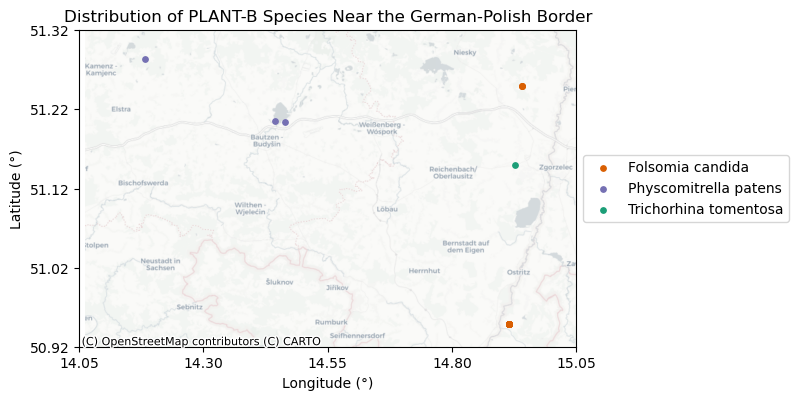

In [26]:
# Set the species colors to match the hvPlot points
species_colors = {
    # Green for the dwarf white isopod
    "Trichorhina tomentosa": "#1b9e77", 
    # Dark orange for the temperate white springtail  
    "Folsomia candida": "#d95f02",        
    # Purple for the spreading earthmoss
    "Physcomitrella patens": "#7570b3"    
}

# Set the figure size 
fig, ax = plt.subplots(figsize=(8, 6))

# Reproject the GDF to match an ESPG of 3857 
gbif_gdf_geography = clipped_gbif_gdf.to_crs(epsg=3857)

# Plot each species on the map
for species, species_border_gdf in gbif_gdf_geography.groupby("species"):
    species_border_gdf.plot(
        ax=ax,
        color=species_colors.get(species, "black"), # Ensure each species keeps their designated color
        label=species,
        markersize=15
    )

# Add the basemap background using contextily
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

# Add labels for the titles and axes
ax.set_title("Distribution of PLANT-B Species Near the German-Polish Border")
ax.set_xlabel("Longitude (°)") # The x-axis will correspond to longitude
ax.set_ylabel("Latitude (°)") # The y-axis will correspond to latitude

# Add the species legend outside the plot map
ax.legend(
    # Anchor the legend on its left side
    loc="center left",
    # Move the anchor just outside the plot map 
    bbox_to_anchor=(1, 0.5), 
    frameon=True)
plt.tight_layout() # Apply a tight layout to avoid clipping the legend

# Generate evenly spaced longitude and latitude ticks in degrees
xticks = np.linspace(minx, maxx, 5)
yticks = np.linspace(miny, maxy, 5)

# Create a transformer to turn the x- and y-axis units back to degrees
transformer = pyproj.Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)

# Convert the x-axis and y-axis tick positions to the projected coordinate system using the transformer
xticks_3857, _ = transformer.transform(xticks, np.full_like(xticks, miny))
_, yticks_3857 = transformer.transform(np.full_like(yticks, minx), yticks)

# Place the ticks at the correct positions on the projected map
ax.set_xticks(xticks_3857)
ax.set_yticks(yticks_3857)
ax.set_xticklabels([f"{x:.2f}" for x in xticks])
ax.set_yticklabels([f"{y:.2f}" for y in yticks])

# Save the plot as a png image to the "Plots" folder
plt.savefig("Plots/PLANT-B_Species_Border_Distribution_Plot.png", dpi=300, bbox_inches="tight")

# Show the plot
plt.show()

In [27]:
# Create a new directory in nutrient_data_dir to store the soil nutrient and microbe data
soil_dir = os.path.join(nutrient_data_dir, 'soil_dir')
os.makedirs(soil_dir, exist_ok=True)

In [31]:
# Inside soil_dir, create a new directory to store the soil nutrient data
soil_nutrient_dir = os.path.join(soil_dir, 'soil_nutrient_dir')
os.makedirs(soil_nutrient_dir, exist_ok=True)

"""The data from the Land Use and Coverage Area frame Survey (LUCAS) 2018 TOPSOIL dataset cannot be downloaded with a function. A request
form must be filled out at https://esdac.jrc.ec.europa.eu/content/lucas-2018-topsoil-data#tabs-0-description=1 so the dataset can be
emailed to you. Livian has already submitted a request and will move the dataset into soil_nutrient_dir when they receive it. Submitting a
second request is not necessary."""

'The data from the Land Use and Coverage Area frame Survey (LUCAS) 2018 TOPSOIL dataset cannot be downloaded with a function. A request\nform must be filled out at https://esdac.jrc.ec.europa.eu/content/lucas-2018-topsoil-data#tabs-0-description=1 so the dataset can be\nemailed to you. Livian has already submitted a request and will move the dataset into soil_nutrient_dir when they receive it. Submitting a\nsecond request is not necessary.'

In [29]:
# Inside soil_dir, create a new directory to store the soil microbe data
soil_microbe_dir = os.path.join(soil_dir, 'soil_microbe_dir')
os.makedirs(soil_microbe_dir, exist_ok=True)

"""The data from the LUCAS 2018 Biodiversity dataset cannot be downloaded with a function. A request form must be filled out at 
https://esdac.jrc.ec.europa.eu/content/soil-biodiversity-dna-bacteria-and-fungi#tabs-0-description=1 so the dataset can be
emailed to you. Livian has already submitted a request and will move the dataset into soil_microbe_dir when they receive it. Submitting a
second request is not necessary."""

'The data from the LUCAS 2018 Biodiversity dataset cannot be downloaded with a function. A request form must be filled out at \nhttps://esdac.jrc.ec.europa.eu/content/soil-biodiversity-dna-bacteria-and-fungi#tabs-0-description=1 so the dataset can be\nemailed to you. Livian has already submitted a request and will move the dataset into soil_microbe_dir when they receive it. Submitting a\nsecond request is not necessary.'